# Dataset visualisation
Overview of the four raw generated datasets.

In [17]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import rasterio
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import geopandas as gpd

DATA = Path('../data')

# 1. Climate grid

In [3]:
ds = xr.open_dataset(DATA / 'climate_grid.nc')
ds

<xarray.Dataset>
Dimensions:        (time: 3652, lat: 50, lon: 50)
Coordinates:
  * time           (time) datetime64[ns] 2014-01-01 2014-01-02 ... 2023-12-31
  * lat            (lat) float32 36.0 36.2 36.41 36.61 ... 45.39 45.59 45.8 46.0
  * lon            (lon) float32 6.0 6.245 6.49 6.735 ... 17.27 17.51 17.76 18.0
Data variables:
    temperature    (time, lat, lon) float32 ...
    humidity       (time, lat, lon) float32 ...
    wind_speed     (time, lat, lon) float32 ...
    precipitation  (time, lat, lon) float32 ...
    ndvi           (time, lat, lon) float32 ...
Attributes:
    title:        Synthetic climate grid 2014-2023
    institution:  Levantia Fire Risk
    source:       generate_data.py
    history:      Created 2026-05-15T11:08:02.554319
    Conventions:  CF-1.8

### Underlying spatial structure (sinusoid) in winter and summer

In [4]:
# data exctraction
summer_day = '2020-07-15'
winter_day = '2020-01-15'

temp_summer = ds['temperature'].sel(time=summer_day, method='nearest')
temp_winter = ds['temperature'].sel(time=winter_day, method='nearest')
wind_summer = ds['wind_speed'].sel(time=summer_day, method='nearest')
wind_winter = ds['wind_speed'].sel(time=winter_day, method='nearest')

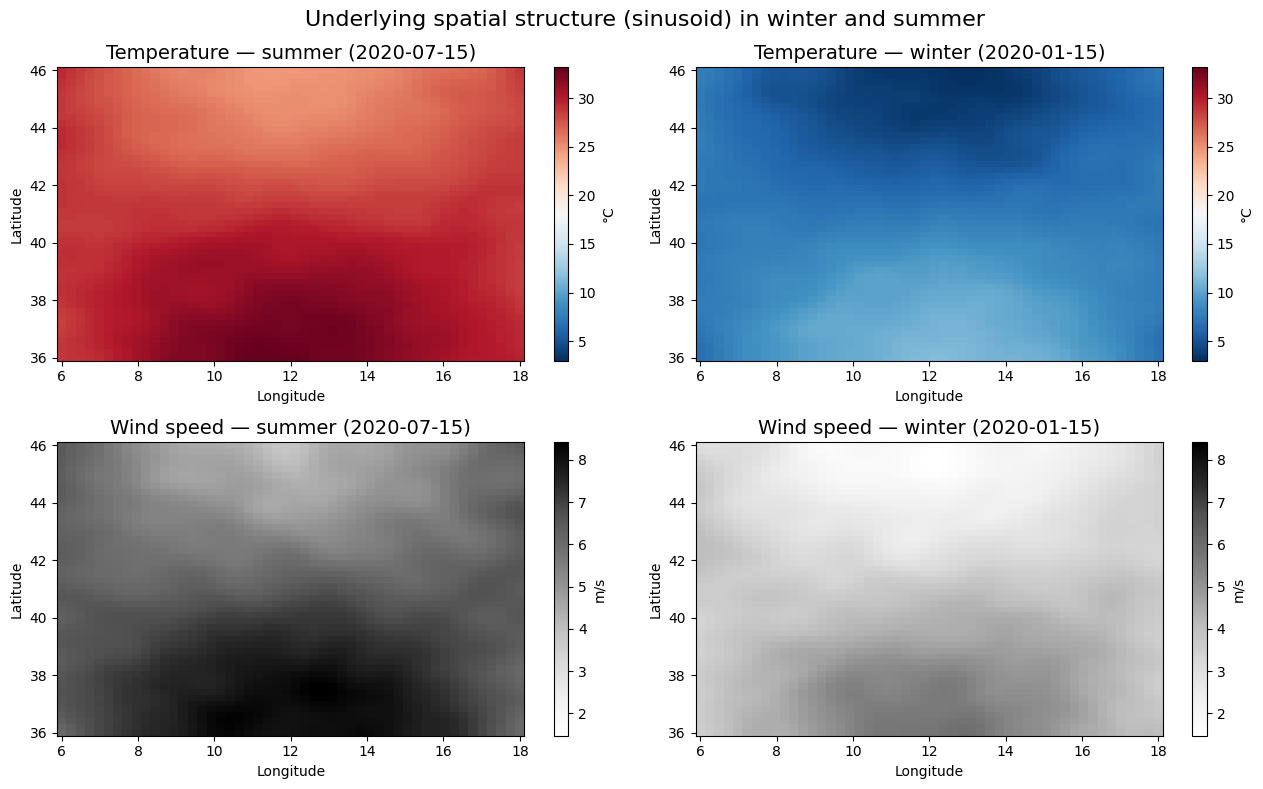

In [5]:
# plot

t_min = min(temp_summer.min(), temp_winter.min()).item()
t_max = max(temp_summer.max(), temp_winter.max()).item()
w_min = min(wind_summer.min(), wind_winter.min()).item()
w_max = max(wind_summer.max(), wind_winter.max()).item()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

temp_summer.plot(ax=axes[0, 0], cmap='RdBu_r', vmin=t_min, vmax=t_max, cbar_kwargs={'label': '°C'})
axes[0, 0].set_title(f'Temperature — summer ({summer_day})', fontsize=14)

temp_winter.plot(ax=axes[0, 1], cmap='RdBu_r', vmin=t_min, vmax=t_max, cbar_kwargs={'label': '°C'})
axes[0, 1].set_title(f'Temperature — winter ({winter_day})', fontsize=14)

wind_summer.plot(ax=axes[1, 0], cmap='Greys', vmin=w_min, vmax=w_max, cbar_kwargs={'label': 'm/s'})
axes[1, 0].set_title(f'Wind speed — summer ({summer_day})', fontsize=14)

wind_winter.plot(ax=axes[1, 1], cmap='Greys', vmin=w_min, vmax=w_max, cbar_kwargs={'label': 'm/s'})
axes[1, 1].set_title(f'Wind speed — winter ({winter_day})', fontsize=14)

for ax in axes.flat:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle("Underlying spatial structure (sinusoid) in winter and summer", fontsize=16)
plt.tight_layout()
plt.show()

### Seasonal structure and later peak of the NVDI

In [6]:
# data extraction
cell_a = dict(lat=44.0, lon=16.0, color='black', marker='^', label='Cell A (north)')
cell_b = dict(lat=37.0, lon=8.0,  color='black', marker='o', label='Cell B (south)')


year      = '2018'
variables = ['temperature', 'humidity', 'wind_speed', 'precipitation', 'ndvi']
summer    = '2018-08-01'
winter    = '2018-02-01'

ds_year  = ds.sel(time=year)
t_summer = ds['temperature'].sel(time=summer, method='nearest')
t_winter = ds['temperature'].sel(time=winter, method='nearest')

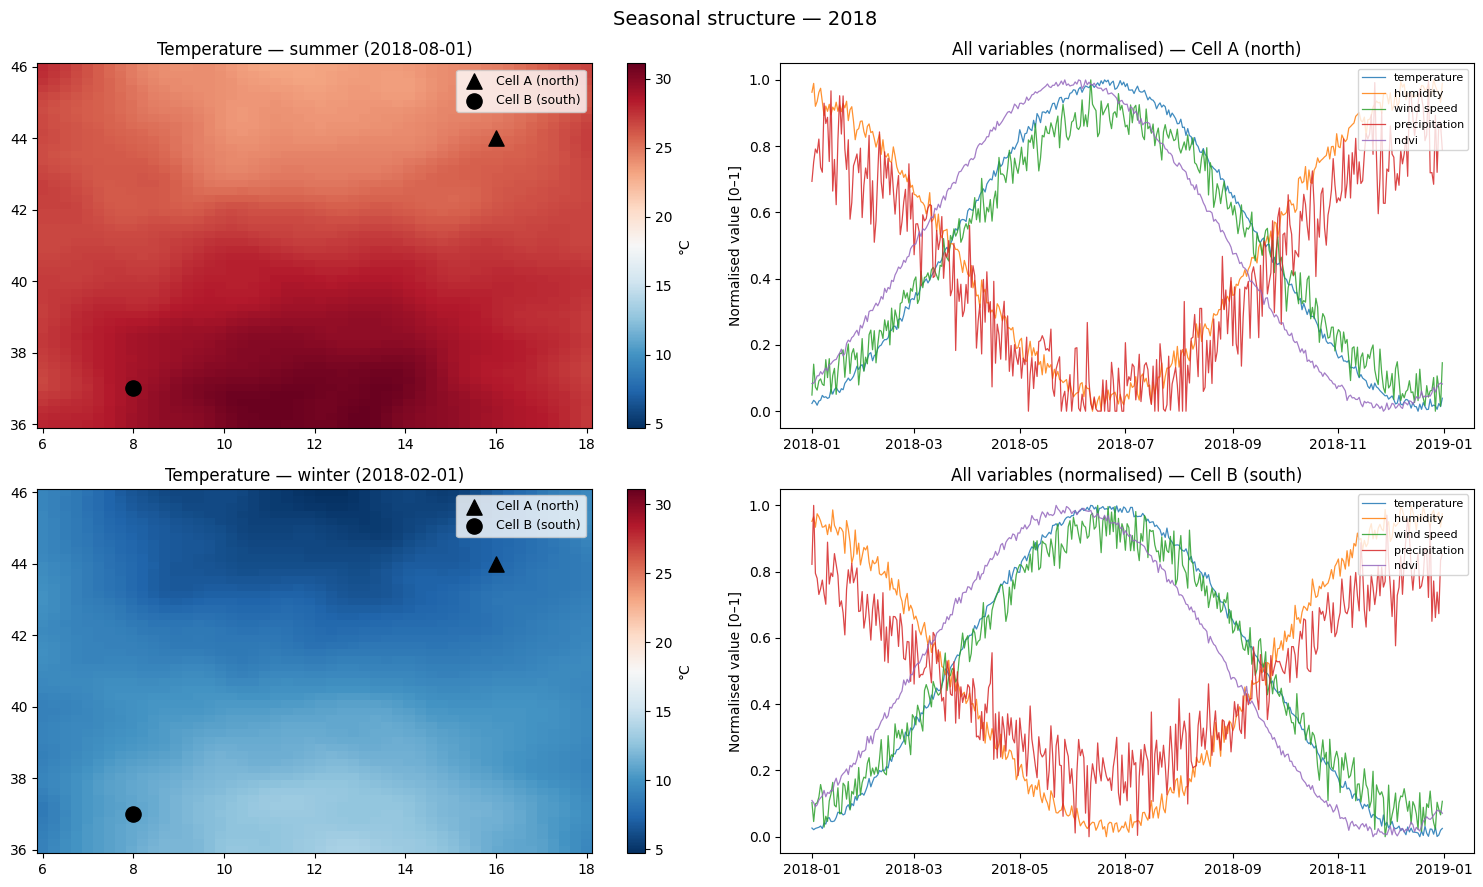

In [7]:
# plot

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

t_min    = min(t_summer.min(), t_winter.min()).item()
t_max    = max(t_summer.max(), t_winter.max()).item()

# --- Top left: summer map ---
t_summer.plot(ax=axes[0, 0], cmap='RdBu_r', vmin=t_min, vmax=t_max,
              cbar_kwargs={'label': '°C'}, add_labels=False)
for cell in (cell_a, cell_b):
    axes[0, 0].scatter(cell['lon'], cell['lat'], color=cell['color'],
                       marker=cell['marker'], s=120, zorder=5, label=cell['label'])
axes[0, 0].legend(fontsize=9)
axes[0, 0].set_title(f'Temperature — summer ({summer})', fontsize=12)

# --- Bottom left: winter map ---
t_winter.plot(ax=axes[1, 0], cmap='RdBu_r', vmin=t_min, vmax=t_max,
              cbar_kwargs={'label': '°C'}, add_labels=False)
for cell in (cell_a, cell_b):
    axes[1, 0].scatter(cell['lon'], cell['lat'], color=cell['color'],
                       marker=cell['marker'], s=120, zorder=5, label=cell['label'])
axes[1, 0].legend(fontsize=9)
axes[1, 0].set_title(f'Temperature — winter ({winter})', fontsize=12)

# --- Right panels: all variables normalised to [0,1] ---
for ax, cell in zip([axes[0, 1], axes[1, 1]], [cell_a, cell_b]):
    for var in variables:
        # data exctraction
        ts      = ds_year[var].sel(lat=cell['lat'], lon=cell['lon'], method='nearest').values
        # data normalization
        ts_norm = (ts - ts.min()) / (ts.max() - ts.min() + 1e-9)
        # plot
        ax.plot(ds_year.time.values, ts_norm, linewidth=0.9, alpha=0.85,
                label=var.replace('_', ' '))
    ax.set_title(f'All variables (normalised) — {cell["label"]}', fontsize=12)
    ax.set_ylabel('Normalised value [0–1]')
    ax.legend(fontsize=8, loc='upper right')

for ax in axes.flat:
    ax.set_xlabel('')

plt.suptitle(f'Seasonal structure — {year}', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Fire events

### Fire events occur in high temperature / low humidity cells

In [8]:
# data extraction
fires = pd.read_csv('../data/fire_events.csv', parse_dates=['date'])

# Pick two fire events on different days
event_1 = fires.iloc[10]
event_2 = fires.iloc[200]

fires

,date,lat,lon,burned_area_ha,duration_days,ignition_cause
0,2014-03-17,37.6327,13.8367,26.9,2,human
1,2014-03-23,44.1633,15.7959,24.9,1,lightning
2,2014-04-18,45.1837,12.8571,26.1,1,unknown
3,2014-04-20,37.0204,10.1633,24.8,1,human
4,2014-04-24,44.9796,12.3673,51.6,1,human
...,...,...,...,...,...,...
795,2023-11-05,41.5102,12.8571,25.7,1,lightning
796,2023-11-15,36.2041,9.6735,17.7,1,human
797,2023-11-20,37.0204,10.6531,8.2,1,arson
798,2023-12-03,38.2449,9.6735,111.2,1,arson


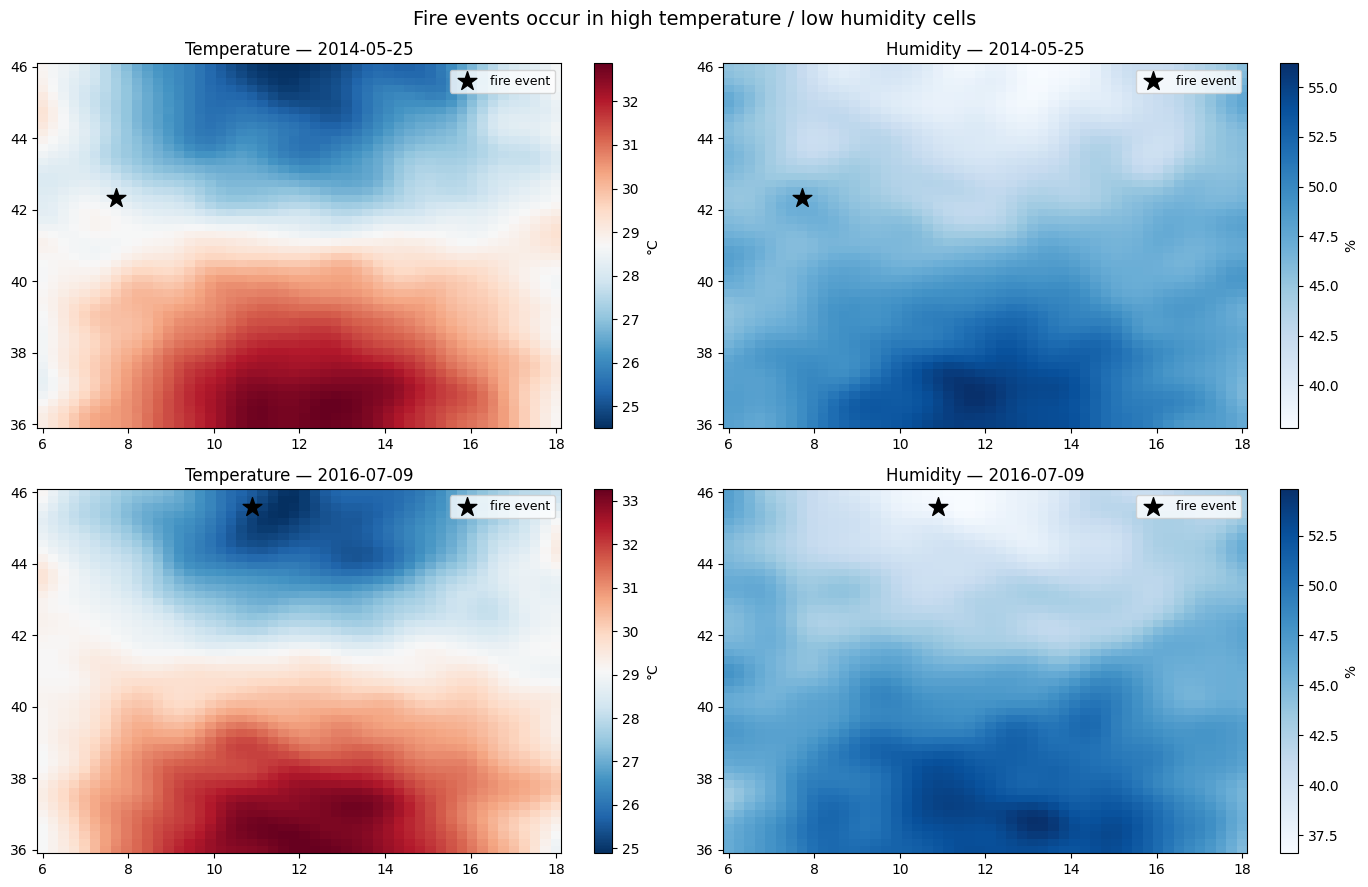

In [9]:
# plot

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row, event in enumerate([event_1, event_2]):
    
    # data extraction
    day  = str(event['date'].date())
    temp = ds['temperature'].sel(time=day, method='nearest')
    hum  = ds['humidity'].sel(time=day, method='nearest')

    # plot
    # Temperature
    temp.plot(ax=axes[row, 0], cmap='RdBu_r', cbar_kwargs={'label': '°C'}, add_labels=False)
    axes[row, 0].scatter(event['lon'], event['lat'], color='black', marker='*',
                         s=200, zorder=5, label='fire event')
    axes[row, 0].legend(fontsize=9)
    axes[row, 0].set_title(f'Temperature — {day}', fontsize=12)

    # Humidity
    hum.plot(ax=axes[row, 1], cmap='Blues', cbar_kwargs={'label': '%'}, add_labels=False)
    axes[row, 1].scatter(event['lon'], event['lat'], color='black', marker='*',
                         s=200, zorder=5, label='fire event')
    axes[row, 1].legend(fontsize=9)
    axes[row, 1].set_title(f'Humidity — {day}', fontsize=12)

plt.suptitle('Fire events occur in high temperature / low humidity cells', fontsize=14)
plt.tight_layout()
plt.show()

### Longer fires span a bigger area

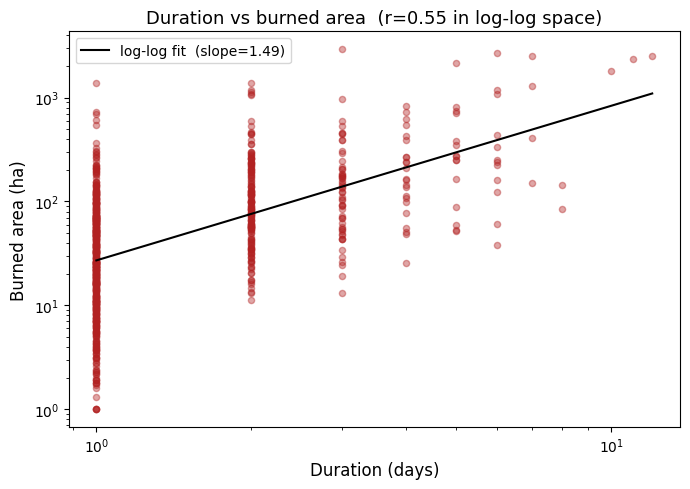

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(fires['duration_days'], fires['burned_area_ha'],
           alpha=0.4, s=20, color='firebrick')

# Log-scale on both axes to handle the heavy right tail
ax.set_xscale('log')
ax.set_yscale('log')

# Regression line in log-log space
log_x = np.log(fires['duration_days'])
log_y = np.log(fires['burned_area_ha'])
m, b  = np.polyfit(log_x, log_y, 1)
x_fit = np.linspace(fires['duration_days'].min(), fires['duration_days'].max(), 100)
ax.plot(x_fit, np.exp(b) * x_fit ** m, color='black', linewidth=1.5,
        label=f'log-log fit  (slope={m:.2f})')

r = np.corrcoef(log_x, log_y)[0, 1]
ax.set_xlabel('Duration (days)', fontsize=12)
ax.set_ylabel('Burned area (ha)', fontsize=12)
ax.set_title(f'Duration vs burned area  (r={r:.2f} in log-log space)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# 3. Land use

In [11]:
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

with rasterio.open('../data/land_use.tif') as src:
    lu     = src.read(1)
    bounds = src.bounds
    # parse class names directly from file metadata
    labels = {int(k): v for k, v in
              (pair.split('=') for pair in src.tags()['classes'].split())}

lu

array([[4, 4, 4, ..., 4, 4, 4],
       [4, 4, 4, ..., 4, 4, 4],
       [4, 4, 4, ..., 4, 4, 4],
       ...,
       [3, 3, 3, ..., 2, 2, 2],
       [3, 3, 3, ..., 2, 2, 2],
       [3, 3, 3, ..., 2, 2, 2]], dtype=uint8)

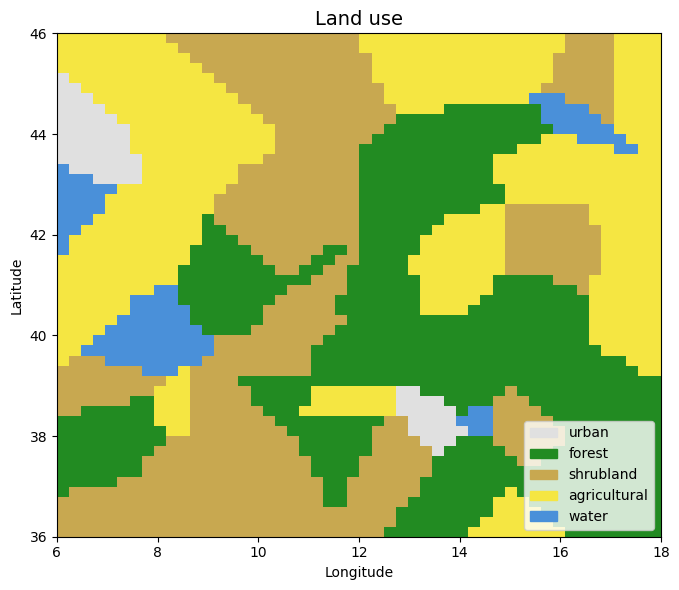

In [12]:
# plot
colors = ['#e0e0e0', '#228b22', '#c8a850', '#f5e642', '#4a90d9']
cmap   = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(lu, cmap=cmap, vmin=0.5, vmax=5.5,
          extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
          origin='upper')
patches = [mpatches.Patch(color=colors[i], label=labels[i+1]) for i in range(5)]
ax.legend(handles=patches, loc='lower right', fontsize=10)
ax.set_title('Land use', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

# 4. Socioeconomic

### Bigger urban centers have denser infrastructures

In [15]:
# data extraction
socio = pd.read_csv('../data/socioeconomic.csv')

log_pop   = np.log(socio['population'])
log_infra = np.log(socio['infrastructure_density'])
m, b = np.polyfit(log_pop, log_infra, 1)
r    = np.corrcoef(log_pop, log_infra)[0, 1]

socio

,municipality_id,population,gdp_per_capita,infrastructure_density
0,MUN_000,8506,35988,7.44
1,MUN_001,756,9764,1.64
2,MUN_002,18974,25477,14.99
3,MUN_003,26716,15813,6.64
4,MUN_004,200,17597,0.82
...,...,...,...,...
295,MUN_295,6753,15223,8.86
296,MUN_296,8373,14644,4.07
297,MUN_297,2516,24960,2.29
298,MUN_298,208,19864,1.66


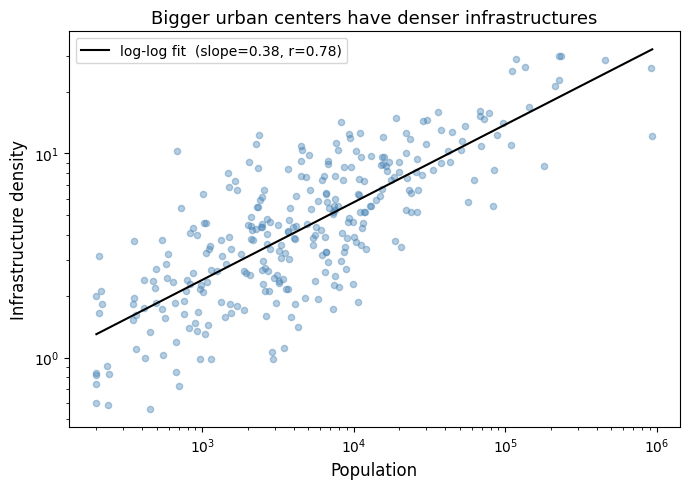

In [16]:
# plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(socio['population'], socio['infrastructure_density'],
           alpha=0.4, s=20, color='steelblue')
ax.set_xscale('log')
ax.set_yscale('log')
x_fit = np.linspace(socio['population'].min(), socio['population'].max(), 100)
ax.plot(x_fit, np.exp(b) * x_fit ** m, color='black', linewidth=1.5,
        label=f'log-log fit  (slope={m:.2f}, r={r:.2f})')
ax.set_xlabel('Population', fontsize=12)
ax.set_ylabel('Infrastructure density', fontsize=12)
ax.set_title('Bigger urban centers have denser infrastructures', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# 5. Municipalities

In [22]:
# data extraction
municipalities = gpd.read_file('../data/municipalities.geojson')
municipalities['area'] = municipalities.geometry.area

municipalities

/var/folders/gy/lfvz5g2n20sg188jjt5spxc40000gn/T/ipykernel_82363/3045076134.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  municipalities['area'] = municipalities.geometry.area


,municipality_id,geometry,area
0,MUN_000,"POLYGON ((15.12363 43.56045, 14.99213 43.66491...",0.238681
1,MUN_001,"POLYGON ((10.97089 37.15282, 11.32201 37.40756...",0.103570
2,MUN_002,"POLYGON ((16.50393 40.93979, 15.89771 40.86407...",0.548309
3,MUN_003,"POLYGON ((14.13883 40.86548, 13.94281 41.10355...",0.426378
4,MUN_004,"POLYGON ((6.00000 43.91757, 6.00000 44.49096, ...",1.271015
...,...,...,...
295,MUN_295,"POLYGON ((17.05936 38.84263, 17.37355 38.55917...",0.349605
296,MUN_296,"POLYGON ((17.58146 42.52834, 17.50632 42.62640...",0.502777
297,MUN_297,"POLYGON ((15.64091 42.73816, 16.02337 41.91412...",0.234213
298,MUN_298,"POLYGON ((14.64181 45.85369, 15.64653 45.91122...",0.294786


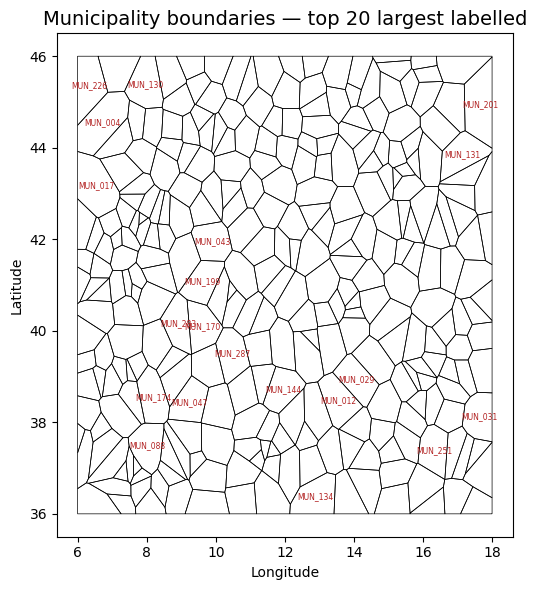

In [23]:
# plot
top20 = municipalities.nlargest(20, 'area')

fig, ax = plt.subplots(figsize=(8, 6))
municipalities.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5)
for _, row in top20.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(cx, cy, row['municipality_id'], fontsize=5.5, ha='center', va='center', color='firebrick')
ax.set_title('Municipality boundaries — top 20 largest labelled', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()